In [1]:
import numpy as np
from scipy import stats
from scipy.ndimage import laplace, sobel, gaussian_filter, uniform_filter
from matplotlib import rc
from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import ListedColormap
rc("font", family="serif")
rc("pgf", texsystem="pdflatex")
rc("text", usetex=True)
# rc('text.latex', unicode=True)
rc("text.latex", preamble=r"\usepackage{amssymb}")
rc("text.latex", preamble=r"\usepackage[T1,T2A]{fontenc}")
rc("text.latex", preamble=r"\usepackage[utf8]{inputenc}")
rc("text.latex", preamble=r"\usepackage[english,russian]{babel}")
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from matplotlib.colors import ListedColormap
from examples.seismic.custom_scripts.mex_4_5.lsrtm.config import setup_model_and_geometry as setup1
from examples.seismic.custom_scripts.mex_6_5.lsrtm.config import setup_model_and_geometry as setup2
from examples.seismic.custom_scripts.mex_4_5.lsrtm.config import PATH_DATA_DSUB as PATH1
from examples.seismic.custom_scripts.mex_6_5.lsrtm.config import PATH_DATA_DSUB as PATH2
from examples.seismic.custom_scripts.mex_4_5.lsrtm.config import OUTPUT_DIRS as OUT1
from examples.seismic.custom_scripts.mex_6_5.lsrtm.config import OUTPUT_DIRS as OUT2
from examples.seismic.custom_scripts.mex_6_5.lsrtm.config import NBL

In [2]:
import pprint

pprint.pprint([PATH1, PATH2, OUT1, OUT2])

['/home/andrey/devito-vti/examples/seismic/data/04-05_dsub.sgy',
 '/home/andrey/devito-vti/examples/seismic/data/06-05_dsub.sgy',
 {'adjoint_snaps': '/mnt/myshare/Андрей/!Аспирантура/mex_4_5/adjoint_snaps',
  'forward_snaps': '/mnt/myshare/Андрей/!Аспирантура/mex_4_5/forward_snaps',
  'gradients': '/mnt/myshare/Андрей/!Аспирантура/mex_4_5/gradients',
  'images': '/mnt/myshare/Андрей/!Аспирантура/mex_4_5/images',
  'results': '/mnt/myshare/Андрей/!Аспирантура/mex_4_5/logs'},
 {'adjoint_snaps': '/mnt/myshare/Андрей/!Аспирантура/mex_6_5/adjoint_snaps',
  'forward_snaps': '/mnt/myshare/Андрей/!Аспирантура/mex_6_5/forward_snaps',
  'gradients': '/mnt/myshare/Андрей/!Аспирантура/mex_6_5/gradients',
  'images': '/mnt/myshare/Андрей/!Аспирантура/mex_6_5/images',
  'results': '/mnt/myshare/Андрей/!Аспирантура/mex_6_5/logs'}]


In [3]:
def process_model(velmodel, dataset, grads, invert_wells=False, scalar=1):
    grad_u0, grad_d0 = grads
    extent = [velmodel.x[0], velmodel.x[-1], velmodel.z[-1], velmodel.z[0]]

    if invert_wells:
        slope2, intercept2, _, _, _ = stats.linregress(dataset.x_coords, dataset.elevations)
        slope1, intercept1, _, _, _ = stats.linregress(dataset.opposite_x, dataset.opposite_elev)
    else:
        slope1, intercept1, _, _, _ = stats.linregress(dataset.x_coords, dataset.elevations)
        slope2, intercept2, _, _, _ = stats.linregress(dataset.opposite_x, dataset.opposite_elev)        

    # Create meshgrid for masking
    x = np.linspace(extent[0], extent[1], grad_u0.shape[0])
    z = np.linspace(extent[3], extent[2], grad_u0.shape[1])
    xx, zz = np.meshgrid(x, z, indexing='ij')

    # Create masks
    # For well1 (left boundary): points should be to the right of well1
    mask1 = xx > (zz - intercept1)/slope1 if slope1 != 0 else xx > intercept1
    # For well2 (right boundary): points should be to the left of well2
    mask2 = xx < (zz - intercept2)/slope2 if slope2 != 0 else xx < intercept2
    # Combined mask (between wells)
    between_wells_mask = mask1 & mask2

    # Apply masks to gradients and image
    grad_d0_masked = laplace(grad_d0) * between_wells_mask
    grad_u0_masked = laplace(grad_u0) * between_wells_mask
    imag0_masked = (laplace(grad_u0) - laplace(grad_d0)) * between_wells_mask

    # grad_d0_masked[grad_d0_masked==0] = np.nan
    # grad_u0_masked[grad_u0_masked==0] = np.nan
    # imag0_masked[imag0_masked==0] = np.nan

    return grad_d0_masked*scalar, grad_u0_masked*scalar, imag0_masked*scalar

In [4]:
model1, dataset1, velmodel1 = setup1(path_data=PATH1)
model2, dataset2, velmodel2 = setup2(path_data=PATH2)
all_grad_u0_1 = np.load(f"{OUT1['gradients']}/grad_full_u_0.npy")
all_grad_d0_1 = np.load(f"{OUT1['gradients']}/grad_full_d_0.npy")
all_grad_u0_2 = np.load(f"{OUT2['gradients']}/grad_full_u_0.npy")
all_grad_d0_2 = np.load(f"{OUT2['gradients']}/grad_full_d_0.npy")

Operator `initdamp` ran in 0.01 s
Operator `initdamp` ran in 0.01 s


In [12]:
grads1 = process_model(velmodel=velmodel1, dataset=dataset1, grads=[all_grad_u0_1, all_grad_d0_1], invert_wells=False, scalar=1)
grads2 = process_model(velmodel=velmodel2, dataset=dataset2, grads=[all_grad_u0_2, all_grad_d0_2], invert_wells=True)

[np.float64(43.5), np.float64(76.80000000000126), np.float64(-260.73000000005413), np.float64(-320.25)]
[np.float64(8.0), np.float64(32.50999999999948), np.float64(-260.790000000054), np.float64(-320.19)]


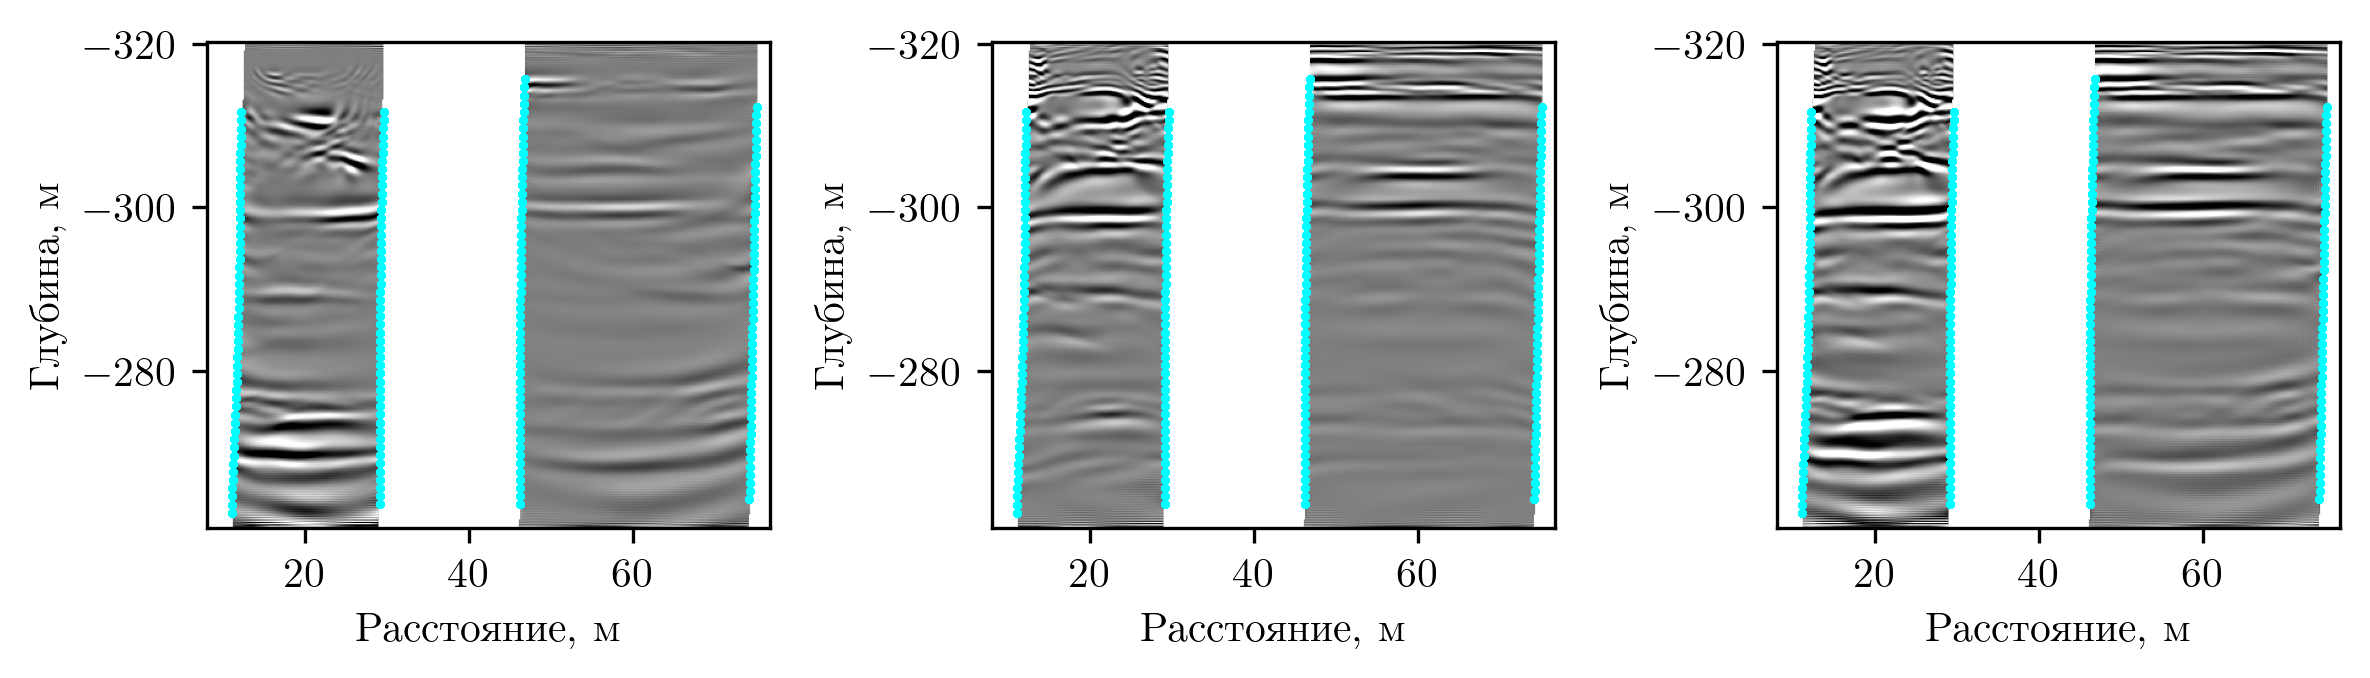

In [15]:
fig, axs = plt.subplots(1, 3, figsize=(8, 4), dpi=300)
glmax = max([np.quantile(grads1[0], 0.99), np.quantile(grads2[0], 0.99)])
for grads, velmodel, model, dataset in zip([grads2, grads1], [velmodel2, velmodel1], [model2, model1], [dataset2, dataset1]):
    extent = [velmodel.x[0], velmodel.x[-1], velmodel.z[-1], velmodel.z[0]]
    print(extent)
    grad_d0, grad_u0, imag0 = grads
    for gr, ax in zip(grads, axs):
        # Create alpha channel: 1 where gr != 0, 0 where gr == 0
        alpha = (gr != 0).astype(float).T
        
        # Apply Laplacian and display with transparency
        h = ax.imshow(gr.T,
                      vmin=-glmax, vmax=glmax,
                      cmap='gray', extent=extent,
                      alpha=alpha)  # Apply the alpha channel here
        
        # Keep the background velocity model as before
        # hh = ax.imshow(model.vp.data[NBL:-NBL, NBL:-NBL].T, 
        #              cmap='jet', vmin=0.5, vmax=5.5, alpha=0.3, extent=extent)
        
        ax.scatter(dataset.x_coords, dataset.elevations, s=1, c='cyan')
        ax.scatter(dataset.opposite_x, dataset.opposite_elev, s=1, c='cyan')

for ax in axs:
    # ax.set_xlim(velmodel2.x[0], velmodel1.x[-1])
    ax.set_xlabel("Расстояние, м")
    ax.set_ylabel("Глубина, м")

plt.tight_layout()
plt.show()